## **Contoh latihan SKIP-GRAM**

# Implementasi Word2Vec (Metode Skip-gram)
*Notebook* ini mendemonstrasikan cara kerja algoritma **Skip-gram** menggunakan library `gensim`. Skip-gram adalah model jaringan saraf tiruan sederhana yang dilatih untuk memprediksi kata-kata konteks (kata di sekitar) berdasarkan satu kata target. Hasil dari pelatihan ini adalah representasi vektor numerik untuk setiap kata (Word Embeddings).

In [2]:
# Import library yang dibutuhkan
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

## 1. Persiapan Data (Korpus)
Kita menggunakan 3 kalimat sederhana. Agar dapat diproses oleh model `Word2Vec` dari Gensim, kalimat-kalimat ini harus dipecah (tokenisasi) menjadi daftar kata individual.

In [3]:
# Definisi 3 kalimat sederhana
kalimat = [
    "kucing mengejar tikus di dapur",
    "anjing bermain bola di taman",
    "kucing dan anjing berlari sangat cepat"
]

# Tokenisasi sederhana dengan memisahkan kata berdasarkan spasi
tokenized_data = [teks.split() for teks in kalimat]

print("Data setelah tokenisasi:")
for i, token in enumerate(tokenized_data):
    print(f"Kalimat {i+1}: {token}")

Data setelah tokenisasi:
Kalimat 1: ['kucing', 'mengejar', 'tikus', 'di', 'dapur']
Kalimat 2: ['anjing', 'bermain', 'bola', 'di', 'taman']
Kalimat 3: ['kucing', 'dan', 'anjing', 'berlari', 'sangat', 'cepat']


## 2. Pelatihan Model Skip-gram
Kita menginisialisasi model `Word2Vec`. Parameter kuncinya adalah:
* `vector_size=5`: Kita mengubah setiap kata menjadi vektor berisi 5 angka (dimensi).
* `window=2`: Model akan melihat 2 kata ke belakang dan 2 kata ke depan sebagai konteks.
* `min_count=1`: Pastikan kata yang muncul minimal 1 kali tetap dimasukkan ke dalam *vocabulary*.
* `sg=1`: **Ini adalah parameter penentu.** Angka 1 menginstruksikan Gensim untuk menggunakan algoritma **Skip-gram** (jika 0, ia akan menggunakan CBOW).

In [4]:
# Latih model Word2Vec dengan metode Skip-gram (sg=1)
model = Word2Vec(sentences=tokenized_data, vector_size=5, window=2, min_count=1, sg=1)

# Mengambil daftar semua kata unik (vocabulary) yang berhasil dipelajari model
vocab = list(model.wv.index_to_key)
print(f"Total kata dalam vocabulary: {len(vocab)} kata")
print("Daftar vocabulary:", vocab)

Total kata dalam vocabulary: 13 kata
Daftar vocabulary: ['anjing', 'di', 'kucing', 'cepat', 'sangat', 'berlari', 'dan', 'taman', 'bola', 'bermain', 'dapur', 'tikus', 'mengejar']


## 3. Ekstraksi Vektor Kata
Sekarang kita panggil beberapa kata dari *vocabulary* untuk melihat bagaimana model Skip-gram mengubah teks tersebut menjadi representasi deretan angka (vektor 5 dimensi).

In [5]:
# Menampilkan representasi vektor dari kata spesifik
kata_target_1 = "kucing"
kata_target_2 = "anjing"

print(f"Vektor untuk kata '{kata_target_1}':")
print(model.wv[kata_target_1])

print(f"\nVektor untuk kata '{kata_target_2}':")
print(model.wv[kata_target_2])

Vektor untuk kata 'kucing':
[ 0.1476101  -0.03066943 -0.09073226  0.13108103 -0.09720321]

Vektor untuk kata 'anjing':
[-0.01072454  0.00472863  0.10206699  0.18018547 -0.186059  ]


## 4. Visualisasi Vektor (Opsional)
Untuk membuktikan bahwa kata-kata ini telah berada dalam ruang vektor, kita bisa menggunakan PCA (*Principal Component Analysis*) untuk mereduksi 5 dimensi angka tadi menjadi 2 dimensi (X dan Y) agar bisa digambar ke dalam grafik *scatter plot*. Kata yang sering muncul di konteks kalimat yang mirip akan berada saling berdekatan.

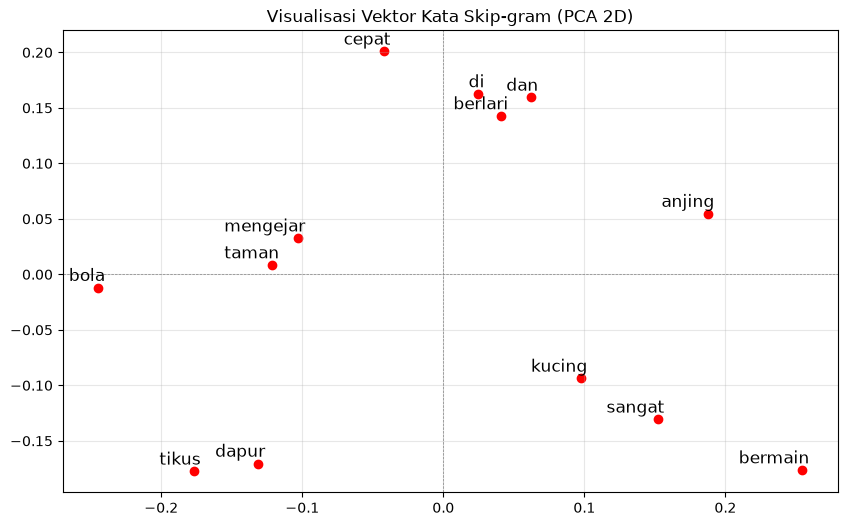

In [6]:
# Mengambil vektor seluruh kata
vektor_semua_kata = model.wv[vocab]

# Reduksi dimensi dari 5 ke 2 menggunakan PCA
pca = PCA(n_components=2)
vektor_2d = pca.fit_transform(vektor_semua_kata)

# Membuat Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(vektor_2d[:, 0], vektor_2d[:, 1], color='red')

# Memberikan label teks pada setiap titik
for i, kata in enumerate(vocab):
    plt.annotate(kata, xy=(vektor_2d[i, 0], vektor_2d[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom', fontsize=12)

plt.title("Visualisasi Vektor Kata Skip-gram (PCA 2D)")
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()